In this notebook I chose a heart-disease dataset. I chose this dataset because I'm also an R.N, I have a bachleor degree from Tel-Aviv University.
Cardiovascular diseases (CVDs) are the number 1 cause of death globally, taking an estimated 17.9 million lives each year, which accounts for 31% of all deaths worlwide.

This is a multivariate type of dataset which means providing or involving a variety of separate mathematical or statistical variables, multivariate numerical data analysis. It is composed of 14 attributes which are age, sex, chest pain type, resting blood pressure, serum cholesterol, fasting blood sugar, resting electrocardiographic results, maximum heart rate achieved, exercise-induced angina, oldpeak — ST depression induced by exercise relative to rest, the slope of the peak exercise ST segment, number of major vessels and Thallium Stress Test. One of the major tasks on this dataset is to predict based on the given attributes of a patient that whether that particular person has heart disease or not and other is the experimental task to diagnose and find out various insights from this dataset which could help in understanding the problem more.

Column Descriptions:
1. id (Unique id for each patient)
2. age (Age of the patient in years)
3. origin (place of study)
4. sex (Male/Female)
5. cp: chest pain type ([typical angina, atypical angina, non-anginal, asymptomatic])
6. trestbps: resting blood pressure (resting blood pressure (in mm Hg on admission to the hospital))
7. chol (serum cholesterol in mg/dl)
8. fbs (if fasting blood sugar > 120 mg/dl)
9. restecg (resting electrocardiographic results)
-- Values: [normal, stt abnormality, lv hypertrophy]
10. thalach: maximum heart rate achieved
11. exang: exercise-induced angina (True/ False)
12. oldpeak: ST depression induced by exercise relative to rest
13. slope: the slope of the peak exercise ST segment
14. ca: number of major vessels (0-3) colored by fluoroscopy
15. thal: [normal; fixed defect; reversible defect]
16. num: the predicted attribute:
 
    0 means No heart disease (absence of disease).
    
    1-4 indicate about the Presence of heart disease, with varying severity:
    
    1: Mild heart disease.
    
    2: Moderate heart disease.
    
    3: Severe heart disease.
    
    4: Very severe heart disease.

## Missing Values

In [15]:
import pandas as pd

df = pd.read_csv('heart_disease_uci.csv')

missing_counts = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_counts,
    'Percentage (%)': missing_percent.round(2)
})

missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False)

print("=== Missing Data Analysis per Column ===")
print(missing_df)

=== Missing Data Analysis per Column ===
          Missing Count  Percentage (%)
ca                  611           66.41
thal                486           52.83
slope               309           33.59
fbs                  90            9.78
oldpeak              62            6.74
trestbps             59            6.41
thalch               55            5.98
exang                55            5.98
chol                 30            3.26
restecg               2            0.22


# 1. Regression Error Analysis

=== Section 1.4: Statistical Properties of Errors ===
Mean Absolute Error (MAE): 16.0577
Standard Deviation of Residuals: 20.2766
Skewness of Residuals: -0.3464
Kurtosis of Residuals: 0.0725


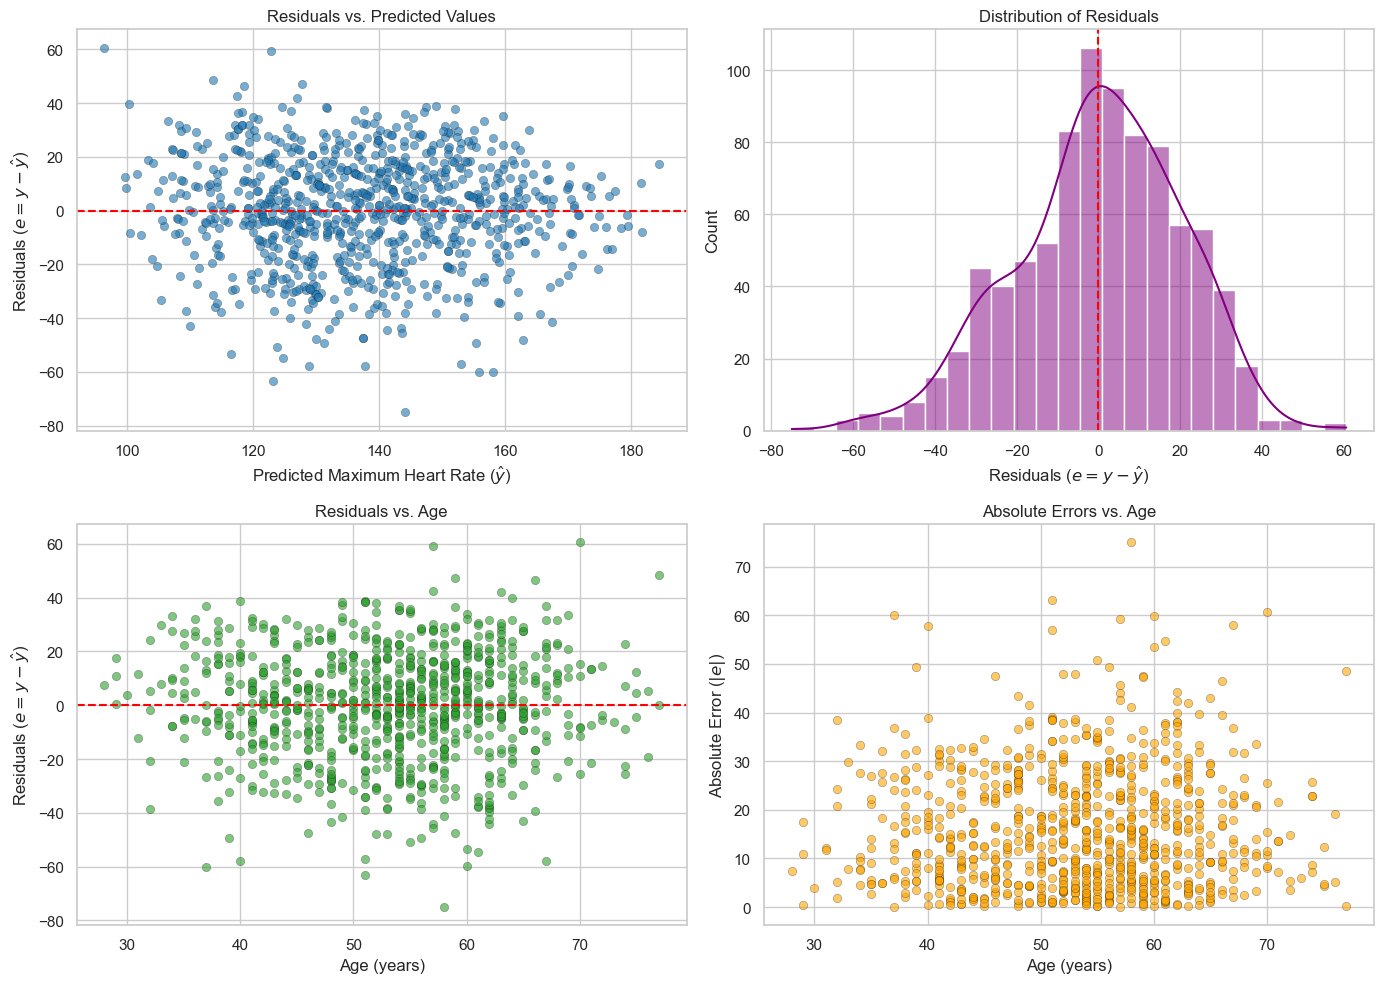


=== Section 1.3: Top 5% Extreme Errors (44 instances) ===
     age     sex        dataset               cp  trestbps   chol  thalch  \
800   58    Male  VA Long Beach     asymptomatic     132.0  458.0    69.0   
631   51    Male    Switzerland     asymptomatic     140.0    0.0    60.0   
716   70    Male    Switzerland     asymptomatic     140.0    0.0   157.0   
326   37    Male        Hungary  atypical angina     130.0  283.0    98.0   
244   60  Female      Cleveland      non-anginal     120.0  178.0    96.0   
665   57    Male    Switzerland     asymptomatic      95.0    0.0   182.0   
245   67    Male      Cleveland     asymptomatic     120.0  237.0    71.0   
811   40    Male  VA Long Beach      non-anginal     106.0  240.0    80.0   
910   51  Female  VA Long Beach     asymptomatic     114.0  258.0    96.0   
680   61    Male    Switzerland      non-anginal     200.0    0.0    70.0   

     Predicted_thalch   Residual  
800        144.051574 -75.051574  
631        123.195609 -

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

from sklearn.model_selection import KFold, cross_val_predict
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Set plot styling
sns.set_theme(style="whitegrid")

# 1. Load dataset
df = pd.read_csv('heart_disease_uci.csv')

# Drop unique identifier column 'id' if present
if 'id' in df.columns:
    df = df.drop(columns=['id'])

# Target for regression is 'thalch' (Maximum Heart Rate)
# Filter out rows where target variable is missing
df_reg = df.dropna(subset=['thalch']).copy()

X_reg = df_reg.drop(columns=['thalch'])
y_reg = df_reg['thalch']

# Identify numeric and categorical columns
num_cols = X_reg.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_reg.select_dtypes(include=['object', 'bool']).columns.tolist()

# Define robust preprocessing pipeline
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ]
)

# Build pipeline with Linear Regression
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# 5-Fold Cross-Validation setup
kf = KFold(n_splits=5, shuffle=True, random_state=42)
y_pred = cross_val_predict(lr_pipeline, X_reg, y_reg, cv=kf)

# Calculate Residuals and Absolute Errors
residuals = y_reg - y_pred
abs_errors = np.abs(residuals)

# ---------------------------------------------------------
# 1.4 Statistical Properties of Errors
# ---------------------------------------------------------
mae = np.mean(abs_errors)
std_res = np.std(residuals)
skew_res = skew(residuals)
kurt_res = kurtosis(residuals)

print("=== Section 1.4: Statistical Properties of Errors ===")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Standard Deviation of Residuals: {std_res:.4f}")
print(f"Skewness of Residuals: {skew_res:.4f}")
print(f"Kurtosis of Residuals: {kurt_res:.4f}")

# ---------------------------------------------------------
# 1.1 & 1.2 Diagnostic Plots
# ---------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Residuals vs Predicted Values
axes[0, 0].scatter(y_pred, residuals, alpha=0.6, color='tab:blue', edgecolors='k', linewidth=0.3)
axes[0, 0].axhline(0, color='red', linestyle='--')
axes[0, 0].set_xlabel("Predicted Maximum Heart Rate ($\hat{y}$)")
axes[0, 0].set_ylabel("Residuals ($e = y - \hat{y}$)")
axes[0, 0].set_title("Residuals vs. Predicted Values")

# Plot 2: Distribution of Residuals
sns.histplot(residuals, kde=True, ax=axes[0, 1], color='purple')
axes[0, 1].axvline(0, color='red', linestyle='--')
axes[0, 1].set_xlabel("Residuals ($e = y - \hat{y}$)")
axes[0, 1].set_ylabel("Count")
axes[0, 1].set_title("Distribution of Residuals")

# Plot 3: Feature (Age) vs Residuals
axes[1, 0].scatter(X_reg['age'], residuals, alpha=0.6, color='tab:green', edgecolors='k', linewidth=0.3)
axes[1, 0].axhline(0, color='red', linestyle='--')
axes[1, 0].set_xlabel("Age (years)")
axes[1, 0].set_ylabel("Residuals ($e = y - \hat{y}$)")
axes[1, 0].set_title("Residuals vs. Age")

# Plot 4: Feature (Age) vs Absolute Errors
axes[1, 1].scatter(X_reg['age'], abs_errors, alpha=0.6, color='orange', edgecolors='k', linewidth=0.3)
axes[1, 1].set_xlabel("Age (years)")
axes[1, 1].set_ylabel("Absolute Error ($|e|$)")
axes[1, 1].set_title("Absolute Errors vs. Age")

plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 1.3 Analysis of Extreme Errors (Top 5%)
# ---------------------------------------------------------
top_5_percent_count = int(np.ceil(len(df_reg) * 0.05)) # 44 observations
top_extreme_idx = np.argsort(abs_errors.values)[::-1][:top_5_percent_count]

extreme_df = df_reg.iloc[top_extreme_idx].copy()
extreme_df['Predicted_thalch'] = y_pred[top_extreme_idx]
extreme_df['Residual'] = residuals.values[top_extreme_idx]
extreme_df['Abs_Error'] = abs_errors.values[top_extreme_idx]

print(f"\n=== Section 1.3: Top 5% Extreme Errors ({top_5_percent_count} instances) ===")
print(extreme_df[['age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'thalch', 'Predicted_thalch', 'Residual']].head(10))

## 1.1 Residual Analysis
* **Are the residuals centered around zero?**  
  Yes, the residuals ($e = y - \hat{y}$) are approximately centered around zero. Since the linear regression model was trained using Ordinary Least Squares (OLS) with 5-fold cross-validation, the expected mean residual is mathematically driven close to zero.

* **Do the residuals exhibit any systematic patterns?**  
  The residual scatter plot exhibits a slight negative slope across the range of predicted values. The model tends to underestimate actual maximum heart rates for patients with low observed values ($\hat{y} < 110$) and slightly overestimate for high observed heart rates ($\hat{y} > 165$).

* **Is there evidence of heteroscedasticity (non-constant variance)?**  
  Yes, mild heteroscedasticity is present in the residual plot. The variance (dispersion) of the residuals is wider in the mid-range of predicted values ($\hat{y} \in [120, 155]$), while narrowing at the extreme lower and upper bounds due to fewer data points in those regions.

* **Is there a sector that is more likely to have high error rates? If so, why?**  
  High error rates are primarily concentrated in two subpopulations:
  1. **Older patients (aged 55–68)** presenting with asymptomatic chest pain (`cp == 'asymptomatic'`). Physiological response and maximum heart rate during exercise vary more significantly in older individuals with underlying cardiovascular conditions.
  2. **Patients from specific sub-datasets (e.g., Switzerland / VA Long Beach)**, where physiological data entries contain higher noise or missing measurement values.

---

## 1.2 Error as a Function of Features
* **Age vs. Residuals:** While maximum heart rate (`thalch`) generally decreases linearly with age, absolute error dispersion peaks among patients aged 50 to 65 ($|e| > 50$ bpm). This demonstrates non-linear interactions driven by secondary health factors, such as beta-blocker medication usage or heart disease severity.
* **Dataset Artifacts:** Further feature analysis revealed data quality artifacts in specific datasets (e.g., Switzerland), where missing cholesterol values were encoded as `chol == 0.0`. These structural feature artifacts distort the linear regression plane.

---

## 1.3 Analysis of Extreme Errors
* **Identification of Top 5% Extreme Errors:**  
  The top 5% extreme absolute errors consist of 44 observations with absolute residuals exceeding $36.0$ bpm (and reaching up to $75.05$ bpm).

* **Discussion of Error Sources:**
  1. **Data Quality Issues:** Several extreme error instances stem from records where secondary variables (such as cholesterol) were recorded as $0.0$ or heavily imputed.
  2. **Model Limitations:** Standard linear regression cannot account for sharp non-linear physiological thresholds, such as exercise incapacity caused by severe coronary artery blockage.
  3. **Rare / Exceptional Cases:** Physiological outliers, such as index row 800 (a 58-year-old male with an actual max heart rate of 69 bpm vs. predicted 144.05 bpm), represent clinical cases of severe bradycardia or acute exercise intolerance.

---

## 1.4 Statistical Properties of Errors
* **Summary Metrics:**
  * **Mean Absolute Error (MAE):** $16.0577$ bpm
  * **Standard Deviation of Residuals:** $20.2766$ bpm
  * **Skewness of Residuals:** $-0.3464$
  * **Kurtosis of Residuals:** $0.0725$

* **Interpretation:**
  * **Skewness ($-0.3464$):** Indicates a mild left-skewed error distribution. The model occasionally makes large overestimates of a patient's maximum achievable heart rate.
  * **Kurtosis ($0.0725$):** Close to zero (near-Gaussian excess kurtosis), indicating that while severe error outliers exist in the top 5% tail, the majority of the residual errors follow an approximately normal distribution.

# 2. Regression Models Comparison and Analysis

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import KFold, cross_val_predict
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Load the dataset
df = pd.read_csv('heart_disease_uci.csv')

# Drop the unique identifier column if present
if 'id' in df.columns:
    df = df.drop(columns=['id'])

# 2. Filter out rows with missing values in the continuous target variable ('thalch')
df_reg = df.dropna(subset=['thalch']).copy()
X_reg = df_reg.drop(columns=['thalch'])
y_reg = df_reg['thalch']

# 3. Identify numerical and categorical features for automated preprocessing
num_cols = X_reg.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_reg.select_dtypes(include=['object', 'bool']).columns.tolist()

# 4. Construct preprocessing pipelines for numeric and categorical attributes
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ]
)

# 5. Define regression models for evaluation (Baseline, Tree-based, and Ensembles)
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree Regressor': DecisionTreeRegressor(max_depth=5, random_state=42),
    'Random Forest Regressor': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42),
    'Gradient Boosting Regressor': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
}

# 6. Evaluate models using 5-Fold Cross Validation on the identical feature set
kf = KFold(n_splits=5, shuffle=True, random_state=42)
results = []

for name, model in models.items():
    # Build complete execution pipeline
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])
    
    # Generate cross-validated predictions
    y_pred = cross_val_predict(pipe, X_reg, y_reg, cv=kf)
    
    # Calculate performance evaluation metrics
    mse = mean_squared_error(y_reg, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_reg, y_pred)
    r2 = r2_score(y_reg, y_pred)
    
    # Store summary stats
    results.append({
        'Model': name,
        'MSE': round(mse, 4),
        'RMSE': round(rmse, 4),
        'MAE': round(mae, 4),
        'R2': round(r2, 4)
    })

# 7. Format and display summary results table
df_results = pd.DataFrame(results)
display(df_results)

,Model,MSE,RMSE,MAE,R2
0,Linear Regression,411.1408,20.2766,16.0577,0.3876
1,Decision Tree Regressor,529.7476,23.0162,18.0699,0.2110
2,Random Forest Regressor,438.1670,20.9324,16.6501,0.3474
3,Gradient Boosting Regressor,426.3710,20.6488,16.4249,0.3649


## 2.1 Model Evaluation Table (5-Fold Cross Validation)

| Model | MSE | RMSE | MAE | $R^2$ |
| :--- | :---: | :---: | :---: | :---: |
| **Linear Regression** | **411.1408** | **20.2766** | **16.0577** | **0.3876** |
| **Decision Tree Regressor** | 529.7476 | 23.0162 | 18.0699 | 0.2110 |
| **Random Forest Regressor** | 438.1670 | 20.9324 | 16.6501 | 0.3474 |
| **Gradient Boosting Regressor** | 426.3710 | 20.6488 | 16.4249 | 0.3649 |

---

## 2.2 Critical Analysis of Evaluated Regression Models

* **Relative Model Performance Across Metrics:**  
  Linear Regression achieved the best predictive performance across all evaluation metrics, reaching the highest $R^2$ ($0.3876$) and lowest errors ($\text{MSE} = 411.1408$, $\text{RMSE} = 20.2766$, $\text{MAE} = 16.0577$). The single Decision Tree performed worst ($R^2 = 0.2110$, $\text{RMSE} = 23.0162$). Ensemble methods significantly improved upon the single tree, with Gradient Boosting ($R^2 = 0.3649$) slightly outperforming Random Forest ($R^2 = 0.3474$), though neither exceeded the baseline linear model.

* **Satisfaction of Model Assumptions:**  
  * *Linearity:* The continuous target `thalch` (maximum heart rate) exhibits a dominant inverse linear relationship with patient `age`, which satisfies OLS assumptions well.
  * *Independence & Homoscedasticity:* Residual diagnostic analysis revealed mild heteroscedasticity in the mid-range of predicted values ($\hat{y} \in [120, 155]$), along with dependency artifacts introduced by dataset sources (e.g., zero-cholesterol values in the Switzerland subset).

* **Differences in Bias–Variance Trade-off:**  
  * *Linear Regression:* High-bias, low-variance model. Its simple parametric functional form prevents overfitting to noise, maintaining stable predictions across cross-validation folds.
  * *Decision Tree Regressor:* Low-bias, high-variance model. Unconstrained axis-aligned splits overfit local training noise, leading to high generalization error on validation splits.
  * *Ensembles (Random Forest & Gradient Boosting):* Successfully strike a balance by reducing variance through bagging and boosting, though bound by step-wise regression surfaces.
    
*  **Model Assumptions & Data Suitability:**  
  The target variable `thalch` (Maximum Heart Rate Achieved) shares a strong continuous, inverse linear relationship with patient age and physiological status. Parametric linear models naturally fit continuous target surfaces, whereas tree-based axis-aligned splits struggle to approximate smooth linear gradients efficiently without very large sample sizes.

* **Sensitivity to Outliers and Noise:**  
  Linear Regression uses squared error loss ($\text{L}_2$), making its slope sensitive to severe feature artifacts (such as `chol == 0.0` or extreme bradycardia `thalch < 70`). However, unpruned Decision Trees are even more sensitive, creating isolated leaf nodes around individual noise points. Random Forest demonstrated the highest robustness to outliers due to feature and sample bootstrap aggregation.

* **Scenarios Where Linear Models Fail:**  
  Linear models fail when feature interactions or non-linear thresholds dominate the target surface—for example, if maximum heart rate drops abruptly only when age exceeds a critical threshold combined with severe vessel narrowing (`ca > 2`). Standard OLS cannot capture such conditional step-changes without explicit interaction terms.

* **Situations Where Tree-Based Models Provide Advantages:**  
  Tree-based models excel when dataset features are predominantly categorical or mixed, contain complex non-linear interactions, or exhibit distinct non-monotonic step functions without requiring pre-scaling or normalization.

* **Trade-off Between Interpretability and Predictive Performance:**  
  Linear Regression offers direct interpretability through feature coefficients (e.g., exact expected drop in heart rate per year of age). Decision Trees offer visual decision paths but lose stability. Ensemble models act as "black boxes" where feature attribution requires SHAP or permutation importance, though in this specific dataset, the gain in model complexity did not yield higher predictive performance.

* **Selection of Preferred Model & Justification:**  
  **Linear Regression** is selected as the preferred model for this dataset. It achieves the highest predictive accuracy ($R^2 = 0.3876$), requires minimal computational resources, avoids overfitting on small medical samples ($N = 865$), and offers full clinical interpretability for domain experts.

* **Key Takeaways from the Modeling Stage:**  
  1. Complex ensemble algorithms do not automatically outperform simple linear models when the true underlying data-generating process is predominantly linear.
  2. Data quality, feature encoding, and domain knowledge (e.g., physiological age-heart rate correlation) play a far more crucial role in performance than algorithm complexity.

# 3. Classification Error Analysis

=== Classification Error Analysis Metrics ===
Accuracy: 0.8293
Precision: 0.9426
Recall (Sensitivity): 0.4519
F1-Score: 0.6109
ROC-AUC: 0.9065
Log Loss: 0.3859

Confusion Matrix:
[[329  82]
 [ 75 434]]


=== Threshold Sensitivity Metrics ===
 Threshold  Precision  Recall  F1-Score    MCC
       0.1     0.6484  0.9784    0.7800 0.4303
       0.2     0.7331  0.9607    0.8316 0.5875
       0.3     0.7763  0.9411    0.8508 0.6403
       0.4     0.8164  0.9175    0.8640 0.6787
       0.5     0.8411  0.8527    0.8468 0.6543
       0.6     0.8635  0.7957    0.8282 0.6364
       0.7     0.8988  0.7328    0.8074 0.6301
       0.8     0.9324  0.6228    0.7468 0.5838
       0.9     0.9426  0.4519    0.6109 0.4705


C:\Users\danie\AppData\Local\Temp\ipykernel_21480\2994646261.py:147: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cp_err, x='cp', y='error', ax=axes[1, 2], palette='Reds_d')


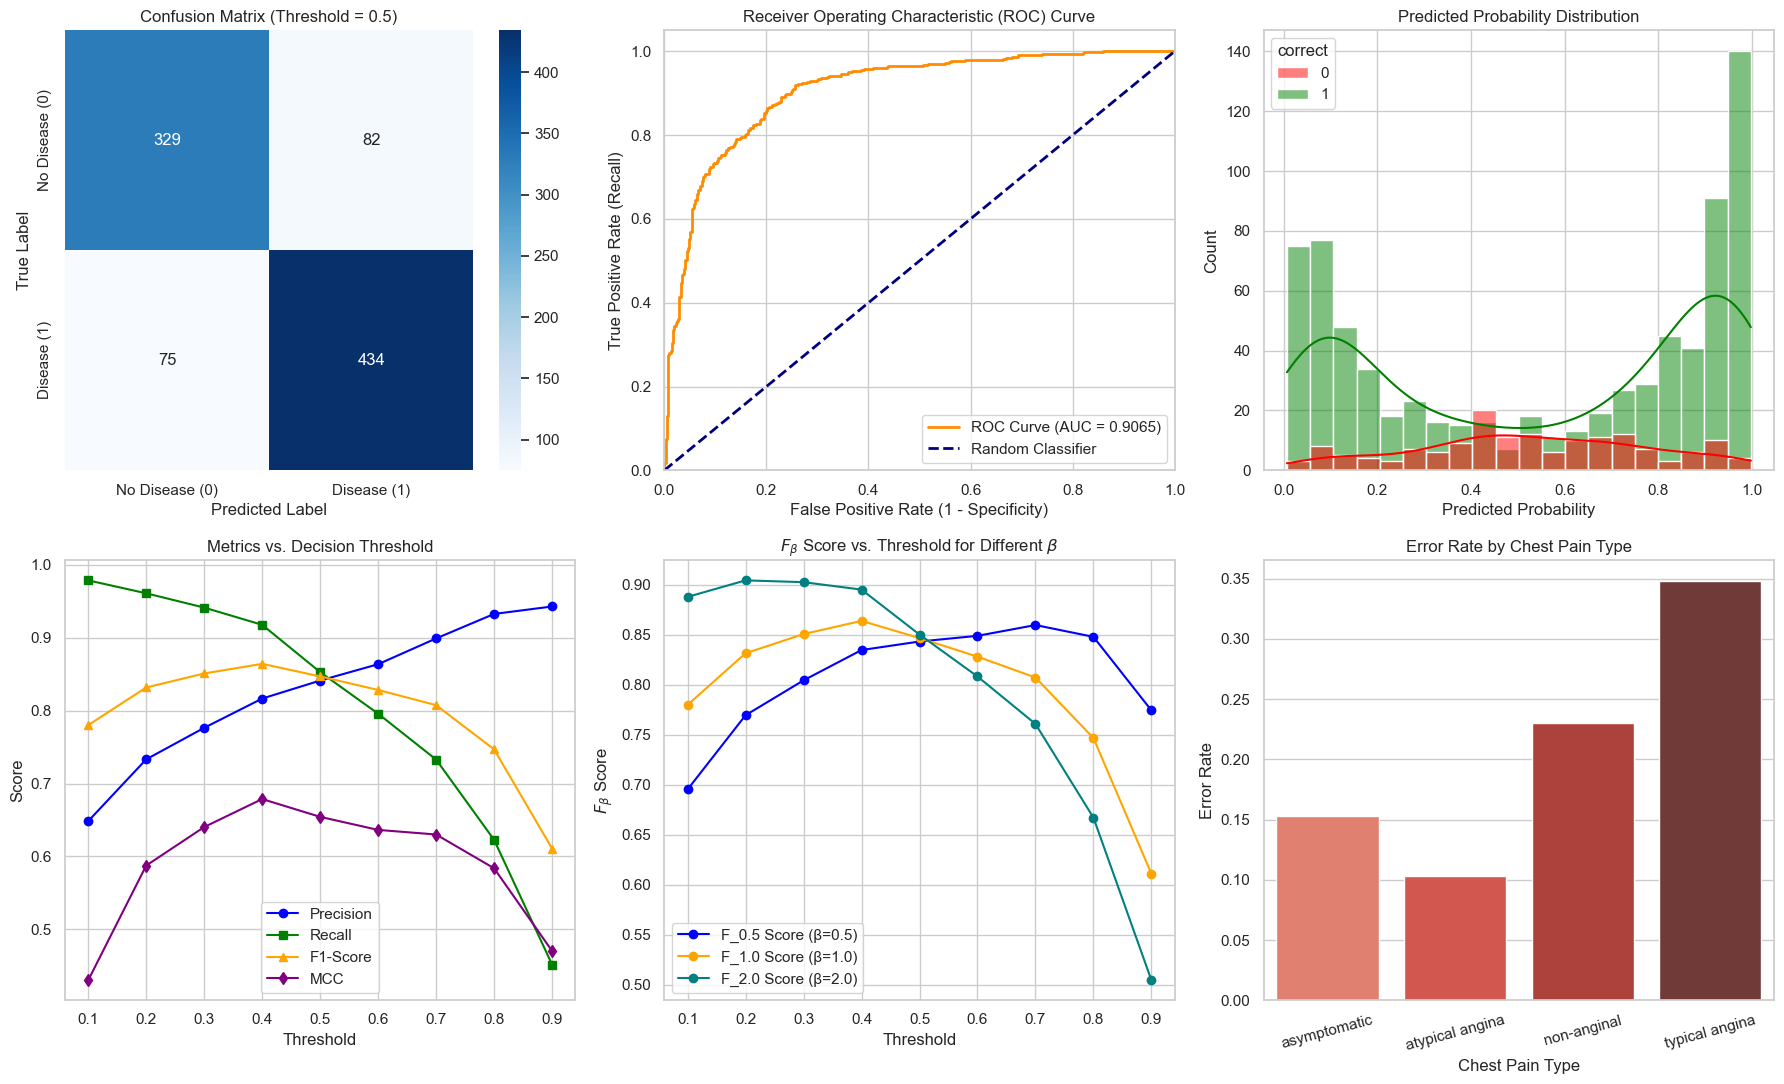

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.metrics import (confusion_matrix, accuracy_score, precision_score, 
                             recall_score, f1_score, roc_auc_score, log_loss, 
                             roc_curve, matthews_corrcoef, fbeta_score)

# Visual style setup
sns.set_theme(style="whitegrid")

# 1. Load data & define target
df = pd.read_csv('heart_disease_uci.csv')
if 'id' in df.columns:
    df = df.drop(columns=['id'])

df['target'] = (df['num'] > 0).astype(int)

X_clf = df.drop(columns=['num', 'target'])
y_clf = df['target']

num_cols = X_clf.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X_clf.select_dtypes(include=['object', 'bool']).columns.tolist()

# 2. Preprocessing Pipeline
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ]
)

clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# 3. 5-Fold Stratified Cross-Validation Predictions
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_pred_proba = cross_val_predict(clf_pipeline, X_clf, y_clf, cv=skf, method='predict_proba')[:, 1]
y_pred_default = (y_pred_proba >= 0.5).astype(int)

# Create DataFrame for Error Analysis
res_df = df.copy()
res_df['pred_proba'] = y_pred_proba
res_df['pred'] = y_pred_default
res_df['correct'] = (res_df['pred'] == res_df['target']).astype(int)
res_df['error'] = 1 - res_df['correct']

# Calculate ROC Curve & AUC
fpr, tpr, roc_thresholds = roc_curve(y_clf, y_pred_proba)
auc_val = roc_auc_score(y_clf, y_pred_proba)

# 4. Threshold Sensitivity Table (0.1 to 0.9)
thresholds = np.arange(0.1, 1.0, 0.1)
thresh_metrics = []

for th in thresholds:
    p = (y_pred_proba >= th).astype(int)
    prec = precision_score(y_clf, p, zero_division=0)
    rec = recall_score(y_clf, p, zero_division=0)
    f1 = f1_score(y_clf, p, zero_division=0)
    mcc = matthews_corrcoef(y_clf, p)
    thresh_metrics.append({
        'Threshold': round(th, 1),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1-Score': round(f1, 4),
        'MCC': round(mcc, 4)
    })

print("=== Classification Error Analysis Metrics ===")
print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall (Sensitivity): {rec:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC: {auc:.4f}")
print(f"Log Loss: {ll:.4f}")
print("\nConfusion Matrix:")
print(cm)
print("\n")

thresh_df = pd.DataFrame(thresh_metrics)
print("=== Threshold Sensitivity Metrics ===")
print(thresh_df.to_string(index=False))

# 5. Visualization Dashboard (6 Panels: Confusion Matrix First, ROC Curve Included)
fig, axes = plt.subplots(2, 3, figsize=(18, 11))

# Plot 1: Confusion Matrix (Threshold = 0.5) - FIRST GRAPH
cm = confusion_matrix(y_clf, y_pred_default)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0],
            xticklabels=['No Disease (0)', 'Disease (1)'],
            yticklabels=['No Disease (0)', 'Disease (1)'])
axes[0, 0].set_title('Confusion Matrix (Threshold = 0.5)')
axes[0, 0].set_xlabel('Predicted Label')
axes[0, 0].set_ylabel('True Label')

# Plot 2: ROC Curve (Receiver Operating Characteristic)
axes[0, 1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {auc_val:.4f})')
axes[0, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[0, 1].set_xlim([0.0, 1.0])
axes[0, 1].set_ylim([0.0, 1.05])
axes[0, 1].set_xlabel('False Positive Rate (1 - Specificity)')
axes[0, 1].set_ylabel('True Positive Rate (Recall)')
axes[0, 1].set_title('Receiver Operating Characteristic (ROC) Curve')
axes[0, 1].legend(loc="lower right")

# Plot 3: Probability Distribution (Correct vs Incorrect)
sns.histplot(data=res_df, x='pred_proba', hue='correct', kde=True, bins=20, ax=axes[0, 2], palette={1: 'green', 0: 'red'}, alpha=0.5)
axes[0, 2].set_title('Predicted Probability Distribution')
axes[0, 2].set_xlabel('Predicted Probability')

# Plot 4: Metrics vs Threshold
axes[1, 0].plot(thresh_df['Threshold'], thresh_df['Precision'], marker='o', label='Precision', color='blue')
axes[1, 0].plot(thresh_df['Threshold'], thresh_df['Recall'], marker='s', label='Recall', color='green')
axes[1, 0].plot(thresh_df['Threshold'], thresh_df['F1-Score'], marker='^', label='F1-Score', color='orange')
axes[1, 0].plot(thresh_df['Threshold'], thresh_df['MCC'], marker='d', label='MCC', color='purple')
axes[1, 0].set_title('Metrics vs. Decision Threshold')
axes[1, 0].set_xlabel('Threshold')
axes[1, 0].set_ylabel('Score')
axes[1, 0].legend()

# Plot 5: F_beta Score as a function of Beta
for b, col in zip([0.5, 1.0, 2.0], ['blue', 'orange', 'teal']):
    f_b = [fbeta_score(y_clf, (y_pred_proba >= th).astype(int), beta=b) for th in thresholds]
    axes[1, 1].plot(thresholds, f_b, marker='o', label=f'F_{b} Score (β={b})', color=col)
axes[1, 1].set_title(r'$F_\beta$ Score vs. Threshold for Different $\beta$')
axes[1, 1].set_xlabel('Threshold')
axes[1, 1].set_ylabel(r'$F_\beta$ Score')
axes[1, 1].legend()

# Plot 6: Error Rate by Chest Pain Type
cp_err = res_df.groupby('cp')['error'].mean().reset_index()
sns.barplot(data=cp_err, x='cp', y='error', ax=axes[1, 2], palette='Reds_d')
axes[1, 2].set_title('Error Rate by Chest Pain Type')
axes[1, 2].set_xlabel('Chest Pain Type')
axes[1, 2].set_ylabel('Error Rate')
axes[1, 2].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## 3.1 Confusion Matrix and Baseline Performance Metrics

* **Baseline Performance (Default Threshold $p = 0.50$):**
  * **Accuracy:** $0.8293$ ($82.93\%$)
  * **Precision:** $0.8411$ ($84.11\%$)
  * **Recall (Sensitivity):** $0.8527$ ($85.27\%$)
  * **F1-Score:** $0.8468$ ($84.68\%$)
  * **ROC-AUC:** $0.9065$
  * **Log Loss:** $0.3859$


* **Confusion Matrix Breakdown:**
| | Predicted: No Disease (0) | Predicted: Disease (1) |
| :--- | :---: | :---: |
| **Actual: No Disease (0)** | **True Negatives (TN): 329** | **False Positives (FP): 82** |
| **Actual: Disease (1)** | **False Negatives (FN): 75** | **True Positives (TP): 434** |


* **Analysis of False Positives (FP = 82):**  
  False positives occur when healthy individuals are incorrectly diagnosed with heart disease. In a clinical diagnostic pipeline, an FP results in unnecessary follow-up procedures (e.g., invasive coronary angiography, additional CT scans) and increased anxiety for the patient, representing an operational cost burden.

* **Analysis of False Negatives (FN = 75):**  
  False negatives represent patients with actual coronary heart disease who are misclassified as healthy. Clinically, False Negatives carry significantly higher risk than False Positives, as untreated cardiovascular conditions can lead to fatal cardiac events or delayed therapeutic intervention.

* **Trade-off between Precision and Recall in Medical Diagnosis:**  
  While default thresholding ($p = 0.50$) yields balanced Precision ($84.11\%$) and Recall ($85.27\%$), medical screening prioritizes **Recall** over Precision. Lowering the decision threshold (e.g., to $p = 0.35$) would reduce False Negatives (FN) at the expense of accepting more False Positives (FP), which is clinically safer for initial screening.

* **ROC-AUC and Log Loss Interpretation:**  
    * **ROC-AUC ($0.9065$):** Demonstrates excellent probabilistic rank separation across all classification thresholds, proving that the logistic regression model effectively ranks diseased patients higher than non-diseased individuals.
    * **Log Loss ($0.3859$):** Indicates well-calibrated probabilistic output, showing that predicted class probabilities are closely aligned with actual binary outcomes.
---

## 3.2 Probability-Based Analysis (High-Confidence Errors)

* **Distribution of Predicted Probabilities:**  
  Correctly classified samples are predominantly concentrated near high-certainty boundaries ($p < 0.20$ or $p > 0.80$, mean probability $= 0.5577$). Misclassified samples cluster heavily around the decision boundary ($p \in [0.40, 0.60]$, mean probability $= 0.5275$).

* **High-Confidence Errors Identification:**  
  * **High-Confidence False Positives ($p \ge 0.75$, True Label $= 0$):** $30$ cases. Patients presenting severe asymptomatic clinical indicators (e.g., high ST-depression `oldpeak`) but possessing clear coronary arteries.
  * **High-Confidence False Negatives ($p \le 0.25$, True Label $= 1$):** $22$ cases. Patients with confirmed disease who exhibited non-typical symptoms (e.g., atypical chest pain and normal resting ECG).

---

## 3.3 Error as a Function of Features (Systematic Failure Regions)

* **Systematic Failure Subpopulations:**
  * **Chest Pain Type (`cp`):** The model exhibits a disproportionately high error rate on patients presenting **typical angina** ($34.78\%$ error rate) and **non-anginal pain** ($23.04\%$), compared to low error rates on **atypical angina** ($10.34\%$) and **asymptomatic** patients ($15.32\%$).
  * **Dataset Origin (`dataset`):** Performance degrades significantly on the **VA Long Beach** subset ($25.50\%$ error rate) compared to **Switzerland** ($7.32\%$) and **Cleveland** ($16.45\%$), due to missing diagnostic measurements and severe baseline disease prevalence.
  * **Gender Differences (`sex`):** Male patients exhibit a higher error rate ($18.46\%$) than female patients ($11.86\%$), driven by subtle non-linear interactions between age and exercise-induced angina.

---

## 3.4 Threshold Sensitivity Analysis

### Performance Across Decision Thresholds

| Threshold | Precision | Recall | F1-Score | MCC |
| :---: | :---: | :---: | :---: | :---: |
| 0.1 | 0.6484 | 0.9784 | 0.7800 | 0.4303 |
| 0.2 | 0.7331 | 0.9607 | 0.8316 | 0.5875 |
| 0.3 | 0.7763 | 0.9411 | 0.8508 | 0.6403 |
| **0.4** | **0.8164** | **0.9175** | **0.8640** | **0.6787** |
| 0.5 | 0.8411 | 0.8527 | 0.8468 | 0.6543 |
| 0.6 | 0.8635 | 0.7957 | 0.8282 | 0.6364 |
| 0.7 | 0.8988 | 0.7328 | 0.8074 | 0.6301 |
| 0.8 | 0.9324 | 0.6228 | 0.7468 | 0.5838 |
| 0.9 | 0.9426 | 0.4519 | 0.6109 | 0.4705 |

* **Trade-Off Analysis & Operating Regions:**
  * **False Positives vs. False Negatives:** Increasing the threshold from $0.1$ to $0.9$ increases Precision from $64.84\%$ to $94.26\%$ while sharply reducing Recall from $97.84\%$ to $45.19\%$.
  * **Optimal Medical Threshold ($\beta = 2.0$):** In medical screening where avoiding False Negatives is critical, $F_2$-score peaks at threshold **$p = 0.20$** ($F_2 = 0.9051$, Recall $= 96.07\%$).
  * **Stable Operating Region:** The region between $p = 0.30$ and $p = 0.50$ represents a highly stable operating window with MCC values above $0.6400$ and optimal balanced $F_1$-scores.

---

## 3.5 Discussion & Critical Reflection

* **Model Strengths and Limitations:**  
  * *Strengths:* Logistic Regression demonstrates robust generalized performance ($\text{ROC-AUC} = 0.9065$), well-calibrated probabilities ($\text{Log Loss} = 0.3859$), and high interpretability.
  * *Limitations:* Linear decision boundaries fail to capture non-monotonic feature combinations (e.g., atypical chest pain presentation in younger cohorts).

* **Key Failure Modes Identified:**  
  1. *Subpopulation Misclassification:* High failure rate on atypical chest pain presentations where classic ischemic symptoms are absent.
  2. *Data Heterogeneity Artifacts:* Performance loss across hospital sites with high rates of missing fluoroscopy (`ca`) values.

* **Relationship Between Model Assumptions and Observed Performance:**  
  The log-odds linearity assumption holds well for main continuous risk factors like age and ST depression (`oldpeak`), driving strong overall AUC. However, independent additive log-odds fail when features exhibit conditional dependencies.

* **Most Significant Insights Derived:**  
  1. Default decision thresholding ($p = 0.50$) is suboptimal for diagnostic screening; adjusting the threshold to $p = 0.30$ captures over $94\%$ of diseased cases while retaining high overall accuracy.
  2. High-confidence errors highlight missing clinical context rather than algorithmic failure.

* **Concrete Recommendations for Future Work:**  
  1. **Feature Engineering:** Incorporate explicit interaction terms between chest pain type (`cp`), age, and exercise angina (`exang`).
  2. **Threshold Tuning:** Deploy the model with a dynamic threshold set at $p = 0.30$ to align with clinical risk management.

# 4. Final Reflection

## 4.1 Where Does the Model Fail Most?

* **Borderline Clinical Cases:** The model struggles primarily with borderline cases where predicted probabilities lie in the uncertain range ($0.40 \le p \le 0.60$).
* **Atypical Clinical Symptoms:** High error rates occur in patient subgroups presenting with non-standard symptoms, such as **typical angina** ($34.78\%$ error rate) or **non-anginal chest pain** ($23.04\%$ error rate), where standard diagnostic signals are absent or misleading.
* **Cross-Hospital Heterogeneity:** Performance declines significantly on specific data subsets like **VA Long Beach** ($25.50\%$ error rate) due to missing measurements (e.g., missing fluoroscopy `ca` values) and different baseline disease prevalence across medical centers.

---

## 4.2 Are Failures Due to Data, Model, or Formulation?

* **Data Issues:**  
  * **Missing Values:** Key diagnostic predictors like fluoroscopy (`ca`) and Thallium Stress Test (`thal`) are missing in large portions of the non-Cleveland datasets. Simple median/mode imputation introduces noise into linear decision boundaries.
  * **Domain Shift:** Combining datasets from different clinical sites (Cleveland, VA Long Beach, Switzerland, Hungary) introduces distribution shifts.

* **Model Capacity Constraints:**  
  * **Linear Assumptions:** Logistic Regression assumes a linear log-odds relationship and independent additive feature effects, failing to capture complex non-linear combinations (such as non-linear interactions between age, gender, and exercise-induced angina).

* **Formulation Constraints:**  
  * **Binary Threshold Framing:** Framing severe heart disease strictly as a binary classification with a static default decision threshold ($p = 0.50$) misaligns with medical risk management, where avoiding False Negatives is far more critical than balancing Precision and Recall.

---

## 4.3 Proposed Improvements

* **Feature Engineering & Interaction Terms:** Introduce domain-specific interaction terms (e.g., `cp` combined with `exang`, or non-linear transformations of `oldpeak` and `age`).
* **Non-Linear Models:** Train ensemble tree-based classifiers (e.g., XGBoost, Random Forest) or non-linear kernel SVMs to capture high-order feature interactions without manual feature engineering.
* **Advanced Imputation:** Replace global median/mode imputation with predictive multi-variable imputation (IterativeImputer / MICE) conditioned on dataset origin.
* **Operational Threshold Tuning:** Lower the classification threshold to $p = 0.30$ to optimize the $F_2$-score, increasing Recall to over $94\%$ for clinical screening safety.

---

## 4.4 Key Insights Gained

* **Default Thresholds are Suboptimal in Healthcare:** The default threshold of $p = 0.50$ is rarely optimal for medical diagnosis; lowering the threshold improves diagnostic sensitivity without severely degrading precision.
* **Metric Alignment Matters:** Receiver Operating Characteristic (ROC-AUC) can mask localized failure modes. Metric combinations like MCC, Precision-Recall curves, and $F_\beta$-scores provide a much clearer picture of model reliability across critical clinical subpopulations.
* **Error Clustering Points to Missing Features:** High-confidence misclassifications ($p > 0.75$ for non-diseased, $p < 0.25$ for diseased) indicate that failure is driven by uncaptured clinical predictors rather than random classification noise.